# Work Flow


1. Dataset
2. Image Processing
3. Train Test split
4. Using Pretrained MobileNet model



In [16]:
# This cell sets up your Kaggle credentials after you've uploaded kaggle.json.
# If you haven't uploaded kaggle.json yet, please do so first via the Files tab.

# Correcting the filename based on available files (e.g., 'kaggle (1).json')
!mkdir -p ~/.kaggle
!mv "kaggle (1).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key configured successfully!")

Kaggle API key configured successfully!


In [17]:
# Now, use the Kaggle CLI to download the 'dogs-vs-cats' dataset.
# The files will be downloaded to the current working directory.

# Install Kaggle if not already installed (it usually is in Colab)
# !pip install kaggle

print("Downloading dogs-vs-cats dataset...")
!kaggle competitions download -c dogs-vs-cats

print("Download complete! You might need to unzip the downloaded files.")

100% 812M/812M [00:04<00:00, 185MB/s]

Download complete! You might need to unzip the downloaded files.


In [18]:
# Example of how to unzip the downloaded files (adjust filenames as needed)
!unzip dogs-vs-cats.zip -d dogs-vs-cats
!unzip dogs-vs-cats/train.zip -d dogs-vs-cats/train
!unzip dogs-vs-cats/test1.zip -d dogs-vs-cats/test
print("Files unzipped.")

Streaming output truncated to the last 5000 lines.
  inflating: dogs-vs-cats/test/test1/55.jpg  
  inflating: dogs-vs-cats/test/test1/550.jpg  
  inflating: dogs-vs-cats/test/test1/5500.jpg  
  inflating: dogs-vs-cats/test/test1/5501.jpg  
  inflating: dogs-vs-cats/test/test1/5502.jpg  
  inflating: dogs-vs-cats/test/test1/5503.jpg  
  inflating: dogs-vs-cats/test/test1/5504.jpg  
  inflating: dogs-vs-cats/test/test1/5505.jpg  
  inflating: dogs-vs-cats/test/test1/5506.jpg  
  inflating: dogs-vs-cats/test/test1/5507.jpg  
  inflating: dogs-vs-cats/test/test1/5508.jpg  
  inflating: dogs-vs-cats/test/test1/5509.jpg  
  inflating: dogs-vs-cats/test/test1/551.jpg  
  inflating: dogs-vs-cats/test/test1/5510.jpg  
  inflating: dogs-vs-cats/test/test1/5511.jpg  
  inflating: dogs-vs-cats/test/test1/5512.jpg  
  inflating: dogs-vs-cats/test/test1/5513.jpg  
  inflating: dogs-vs-cats/test/test1/5514.jpg  
  inflating: dogs-vs-cats/test/test1/5515.jpg  
  inflating: dogs-vs-cats/test/test1/5516

In [19]:
import os
# counting the number of files in the train folder
path, dirs, files =  next(os.walk('/content/dogs-vs-cats/train/train'))
file_count = len(files)
print(file_count)

25000


# Printing the names of images

In [20]:
file_name = os.listdir('/content/dogs-vs-cats/train/train')
print(file_name)

['cat.10318.jpg', 'cat.5276.jpg', 'dog.9860.jpg', 'cat.4203.jpg', 'cat.7286.jpg', 'dog.10384.jpg', 'cat.4235.jpg', 'dog.2451.jpg', 'dog.9234.jpg', 'cat.3240.jpg', 'dog.6019.jpg', 'cat.2944.jpg', 'cat.10158.jpg', 'cat.2929.jpg', 'cat.4179.jpg', 'dog.1415.jpg', 'cat.7600.jpg', 'dog.8491.jpg', 'cat.9172.jpg', 'cat.9918.jpg', 'dog.3832.jpg', 'dog.8398.jpg', 'dog.4491.jpg', 'dog.5394.jpg', 'dog.1235.jpg', 'cat.10142.jpg', 'dog.9179.jpg', 'dog.6584.jpg', 'cat.11204.jpg', 'cat.5395.jpg', 'cat.10847.jpg', 'dog.7986.jpg', 'dog.9819.jpg', 'dog.10838.jpg', 'dog.3408.jpg', 'cat.6653.jpg', 'dog.2840.jpg', 'dog.10494.jpg', 'dog.5076.jpg', 'cat.7390.jpg', 'cat.5525.jpg', 'dog.4677.jpg', 'dog.7765.jpg', 'cat.11930.jpg', 'dog.12402.jpg', 'cat.3798.jpg', 'cat.1989.jpg', 'dog.6940.jpg', 'cat.3408.jpg', 'dog.5906.jpg', 'dog.9477.jpg', 'dog.1400.jpg', 'cat.4078.jpg', 'dog.7249.jpg', 'dog.3585.jpg', 'dog.7761.jpg', 'dog.11728.jpg', 'cat.3549.jpg', 'dog.2317.jpg', 'dog.10210.jpg', 'dog.1545.jpg', 'dog.6137.j

# Importing the dependencies

In [21]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mping
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow

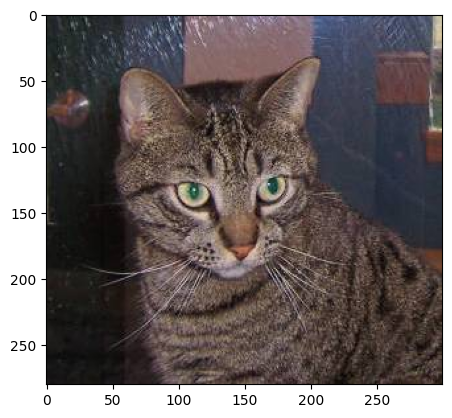

In [29]:
#display dog image
img_cat = mping.imread('/content/dogs-vs-cats/train/train/cat.1.jpg')
plt.imshow(img_cat)

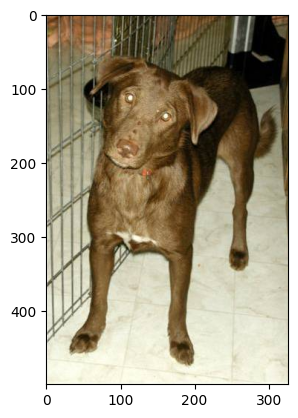

In [30]:
img_dog = mping.imread('/content/dogs-vs-cats/train/train/dog.1.jpg')
plt.imshow(img_dog)

In [31]:
print(img_cat.shape, img_dog.shape)

(280, 300, 3) (499, 327, 3)


# Resizing all the images

In [34]:
file_name = os.listdir('/content/dogs-vs-cats/train/train')
for i in range(5):
  print(file_name[i][0:3])

cat
cat
dog
cat
cat


In [39]:
file_name = os.listdir('/content/dogs-vs-cats/train/train')
dog_count = 0
cat_count = 0
for img_file in file_name:
  name = img_file[0:3]
  if name == 'cat':
    cat_count += 1
  else:
    dog_count += 1
print('Dog count:',dog_count,'\n'  'cat count:', cat_count)


Dog count: 12500 
cat count: 12500


# Resizing all images

In [45]:
#creating a directry fr resied images
os.mkdir('/content/imag_resized')

In [46]:
original_folder = '/content/dogs-vs-cats/train/train'
resized_folder = '/content/imag_resized'
for i in range(2000):
  filename = os.listdir(original_folder)[i]
  img_path = os.path.join(original_folder, filename)
  img = Image.open(img_path)
  resized_img = img.resize((224, 224))
  resized_img = resized_img.convert('RGB')
  resized_img_path = os.path.join(resized_folder, filename)
  resized_img.save(resized_img_path)

In [52]:
resized_file_names = os.listdir('/content/imag_resized')
resized_file_names

['cat.10318.jpg',
 'cat.5276.jpg',
 'dog.9860.jpg',
 'cat.4203.jpg',
 'cat.7286.jpg',
 'dog.10384.jpg',
 'cat.4235.jpg',
 'dog.2451.jpg',
 'dog.9234.jpg',
 'cat.3240.jpg',
 'dog.6019.jpg',
 'cat.2944.jpg',
 'cat.10158.jpg',
 'cat.2929.jpg',
 'cat.4179.jpg',
 'dog.1415.jpg',
 'cat.7600.jpg',
 'dog.8491.jpg',
 'cat.9172.jpg',
 'cat.9918.jpg',
 'dog.3832.jpg',
 'dog.8398.jpg',
 'dog.4491.jpg',
 'dog.5394.jpg',
 'dog.1235.jpg',
 'cat.10142.jpg',
 'dog.9179.jpg',
 'dog.6584.jpg',
 'cat.11204.jpg',
 'cat.5395.jpg',
 'cat.10847.jpg',
 'dog.7986.jpg',
 'dog.9819.jpg',
 'dog.10838.jpg',
 'dog.3408.jpg',
 'cat.6653.jpg',
 'dog.2840.jpg',
 'dog.10494.jpg',
 'dog.5076.jpg',
 'cat.7390.jpg',
 'cat.5525.jpg',
 'dog.4677.jpg',
 'dog.7765.jpg',
 'cat.11930.jpg',
 'dog.12402.jpg',
 'cat.3798.jpg',
 'cat.1989.jpg',
 'dog.6940.jpg',
 'cat.3408.jpg',
 'dog.5906.jpg',
 'dog.9477.jpg',
 'dog.1400.jpg',
 'cat.4078.jpg',
 'dog.7249.jpg',
 'dog.3585.jpg',
 'dog.7761.jpg',
 'dog.11728.jpg',
 'cat.3549.jpg',
 'd

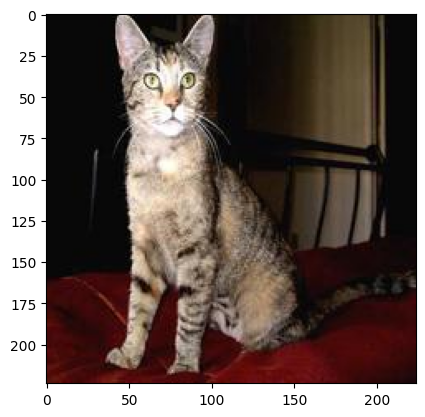

In [49]:
# display resized cat image
img_cat = mping.imread('/content/imag_resized/cat.10000.jpg')
plt.imshow(img_cat)

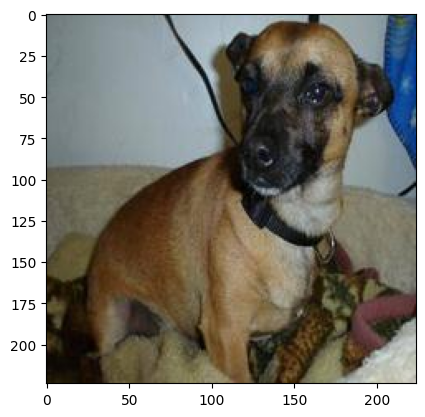

In [53]:
# display resized dog image
img_dog = mping.imread('/content/imag_resized/dog.11905.jpg')
plt.imshow(img_dog)


In [54]:
print(img_cat.shape, img_dog.shape)

(224, 224, 3) (224, 224, 3)


# Creating labels for resized images
1. cat-->0
2. dog-->1

In [56]:
# creating a for loop to assign labels
file_name = os.listdir('/content/imag_resized')
labels = []
for i in range(2000):
  name = file_name[i][0:3]
  if name == 'cat':
    labels.append(0)
  else:
    labels.append(1)



In [62]:
print(file_name[0:5])
print(labels[0:5])

['cat.10318.jpg', 'cat.5276.jpg', 'dog.9860.jpg', 'cat.4203.jpg', 'cat.7286.jpg']
[0, 0, 1, 0, 0]


In [87]:
values , counts = np.unique(labels, return_counts=True)
print(values, counts)

[0 1] [1016  984]


# Converting all the resized images to numpy array

In [67]:
import cv2
import glob

In [68]:
image_directory = '/content/imag_resized/'
image_extension = ['png','jpg']

files = []

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [70]:
dog_cat_images.shape
dog_cat_images

array([[[[161, 153, 146],
         [164, 156, 149],
         [165, 157, 150],
         ...,
         [ 90,  97,  92],
         [ 94, 101,  98],
         [ 79,  86,  83]],

        [[160, 152, 145],
         [163, 155, 148],
         [165, 157, 150],
         ...,
         [ 89,  96,  91],
         [ 87,  94,  91],
         [ 67,  74,  71]],

        [[159, 151, 144],
         [162, 154, 147],
         [164, 156, 149],
         ...,
         [ 92,  98,  93],
         [ 85,  90,  88],
         [ 58,  63,  61]],

        ...,

        [[193, 187, 192],
         [188, 182, 187],
         [183, 177, 182],
         ...,
         [173, 172, 176],
         [171, 169, 175],
         [170, 168, 174]],

        [[189, 183, 188],
         [186, 180, 185],
         [184, 178, 183],
         ...,
         [174, 173, 177],
         [171, 169, 175],
         [170, 168, 174]],

        [[183, 177, 182],
         [183, 177, 182],
         [183, 177, 182],
         ...,
         [175, 174, 178],
        

In [71]:
X = dog_cat_images
Y = np.asarray(labels)

# Train Test Split

In [72]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [73]:
print(X.shape, X_train.shape, X_test.shape)

(2000, 224, 224, 3) (1600, 224, 224, 3) (400, 224, 224, 3)


In [74]:
# scaling the data
X_train_scaled = X_train/255
X_test_scaled = X_test/255

# Building the Neural Network

In [77]:
import tensorflow as tf

In [89]:
import kagglehub

# Download latest version
path = kagglehub.model_download("google/mobilenet-v2/tensorFlow2/100-224-classification")

print("Path to model files:", path)

Path to model files: /kaggle/input/mobilenet-v2/tensorflow2/100-224-classification/2


In [90]:
pretrained_model = path

In [98]:
num_of_classes = 2

# Load the pretrained model
loaded_pretrained_model = tf.keras.layers.TFSMLayer(pretrained_model, call_endpoint='serving_default')

# Freeze the pretrained layer to avoid naming conflicts with the optimizer
loaded_pretrained_model.trainable = False

# Define the model using the Functional API
inputs = tf.keras.Input(shape=(224, 224, 3))
outputs_dict = loaded_pretrained_model(inputs)

# Extract the tensor output
x = list(outputs_dict.values())[0]

# Add pooling if the output is 4D
if len(x.shape) == 4:
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

outputs = tf.keras.layers.Dense(num_of_classes, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tfsm_layer_5 (TFSMLayer)        │ (None, 1001)           │     3,540,265 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         2,004 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,542,269 (13.51 MB)

 Trainable params: 2,004 (7.83 KB)

 Non-trainable params: 3,540,265 (13.51 MB)

In [99]:
# Training the model with the frozen base layer
model.fit(X_train_scaled, Y_train, epochs=5)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.8838 - loss: 0.2687
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9800 - loss: 0.0543
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9875 - loss: 0.0338
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9944 - loss: 0.0238
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9962 - loss: 0.0178


In [100]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print(f'Test Accuracy: {accuracy * 100:.2f}%')
print(f'Test Loss: {loss:.4f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 949ms/step - accuracy: 0.9750 - loss: 0.0698
Test Accuracy: 97.50%
Test Loss: 0.0698


# Predictive System

Enter the path to the input image: /content/cat.jpg


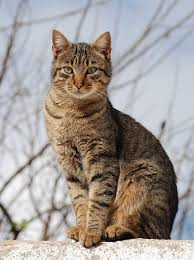

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
[[9.994855e-01 5.144444e-04]]
The image is a cat


In [102]:
input_image_path = input("Enter the path to the input image: ")

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (224, 224))

input_image_scaled = input_image_resized / 255.0

input_image_reshaped = np.expand_dims(input_image_scaled, axis=0)

prediction = model.predict(input_image_reshaped)
print('cat / dog:', prediction)

input_pred_label = np.argmax(prediction)
if input_pred_label == 0:
  print('The image is a cat')
else:
  print('The image is a dog')

Enter the path to the input image: /content/dog.jpg


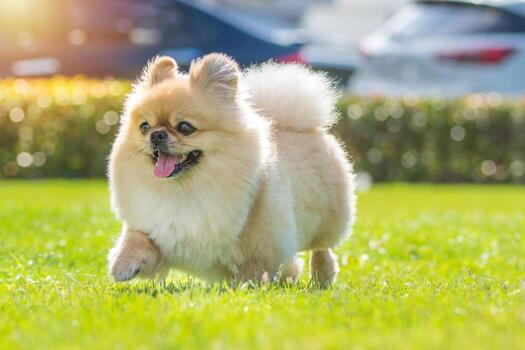

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
cat / dog: [[0.155248 0.844752]]
The image is a dog


In [103]:
input_image_path = input("Enter the path to the input image: ")

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (224, 224))

input_image_scaled = input_image_resized / 255.0

input_image_reshaped = np.expand_dims(input_image_scaled, axis=0)

prediction = model.predict(input_image_reshaped)
print('cat / dog:', prediction)

input_pred_label = np.argmax(prediction)
if input_pred_label == 0:
  print('The image is a cat')
else:
  print('The image is a dog')